# Task 1C — Model Training, Tuning & Experiment Comparison

Target: weekly `Weekly_Sales` per Store-Department.
Evaluation metric: the competition's own **WMAE** (Weighted Mean Absolute
Error), which weights holiday weeks 5x more than regular weeks — a more
business-relevant metric than plain MAE, since holiday-week accuracy
matters most for staffing/inventory decisions.

Because this is a time series, the train/test split is **chronological**
(no random shuffling), and hyperparameter search cross-validation uses
`TimeSeriesSplit` rather than ordinary K-Fold, so that no fold ever trains
on data from after the point it's validated on.

In [1]:
import sys, time, json
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

from src.data_loader import load_merged
from src.preprocessing import build_feature_frame, FEATURE_COLUMNS, TARGET_COLUMN

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

## Build the modeling frame

In [2]:
merged = load_merged()
feat_df = build_feature_frame(merged)

model_df = feat_df.dropna(subset=FEATURE_COLUMNS + [TARGET_COLUMN]).copy()
print("Rows before dropping incomplete lag/rolling windows:", len(feat_df))
print("Rows after:", len(model_df), f"({len(model_df)/len(feat_df)*100:.1f}% retained)")

SPLIT_DATE = "2012-09-01"
train_df = model_df[model_df["Date"] < SPLIT_DATE]
test_df = model_df[model_df["Date"] >= SPLIT_DATE]
print(f"Train: {train_df.shape}, weeks up to {train_df['Date'].max().date()}")
print(f"Test : {test_df.shape}, weeks from {test_df['Date'].min().date()} to {test_df['Date'].max().date()}")

X_train, y_train = train_df[FEATURE_COLUMNS], train_df[TARGET_COLUMN]
X_test, y_test = test_df[FEATURE_COLUMNS], test_df[TARGET_COLUMN]
holiday_test = test_df["IsHoliday"].values

# Downcast to float32/int32 to roughly halve the in-memory footprint — this
# machine has limited free RAM, and RandomizedSearchCV's parallel workers
# each hold a copy of the training data.
for col in X_train.columns:
    if X_train[col].dtype == "int64":
        X_train[col] = X_train[col].astype("int32")
        X_test[col] = X_test[col].astype("int32")
    elif X_train[col].dtype == "float64":
        X_train[col] = X_train[col].astype("float32")
        X_test[col] = X_test[col].astype("float32")
y_train = y_train.astype("float32")

# Hyperparameter search runs on a random subsample of the training rows to
# keep memory/runtime bounded; the winning configuration is then refit on
# the FULL training set (done per-experiment below).
SEARCH_SAMPLE_SIZE = 120_000
rng = np.random.RandomState(42)
if len(X_train) > SEARCH_SAMPLE_SIZE:
    sample_idx = rng.choice(len(X_train), size=SEARCH_SAMPLE_SIZE, replace=False)
    sample_idx.sort()  # keep chronological order intact for TimeSeriesSplit
    X_search, y_search = X_train.iloc[sample_idx], y_train.iloc[sample_idx]
else:
    X_search, y_search = X_train, y_train
print("Full training rows:", len(X_train), "| Search subsample rows:", len(X_search))

Rows before dropping incomplete lag/rolling windows: 421570
Rows after: 395604 (93.8% retained)
Train: (371909, 29), weeks up to 2012-08-31
Test : (23695, 29), weeks from 2012-09-07 to 2012-10-26
Full training rows: 371909 | Search subsample rows: 120000


## Metric: Weighted Mean Absolute Error (WMAE)

In [3]:
def wmae(y_true, y_pred, is_holiday):
    weights = np.where(is_holiday, 5, 1)
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)


def evaluate(name, model, X_te, y_te, is_holiday, fit_seconds, best_params, cv_score=None):
    preds = model.predict(X_te)
    return {
        "experiment": name,
        "best_params": best_params,
        "cv_score(neg_MAE)": cv_score,
        "test_RMSE": round(mean_squared_error(y_te, preds) ** 0.5, 2),
        "test_MAE": round(mean_absolute_error(y_te, preds), 2),
        "test_WMAE": round(wmae(y_te.values, preds, is_holiday), 2),
        "fit_time_sec": round(fit_seconds, 1),
    }


results = []
tscv = TimeSeriesSplit(n_splits=3)

## Experiment 1 — Linear Regression (baseline, no tuning)

A simple linear baseline establishes the floor every subsequent model must
beat.

In [4]:
t0 = time.time()
lr = LinearRegression()
lr.fit(X_train, y_train)
fit_time = time.time() - t0

results.append(evaluate("1. Linear Regression (baseline)", lr, X_test, y_test, holiday_test,
                         fit_time, best_params="n/a (no hyperparameters)"))
results[-1]

{'experiment': '1. Linear Regression (baseline)',
 'best_params': 'n/a (no hyperparameters)',
 'cv_score(neg_MAE)': None,
 'test_RMSE': 3308.26,
 'test_MAE': 1684.31,
 'test_WMAE': np.float64(1785.7),
 'fit_time_sec': 0.6}

## Experiment 2 — Random Forest Regressor (hyperparameter-tuned)

Tuned via `RandomizedSearchCV` over number of trees, depth, and leaf/split
sizes, using time-series-aware cross-validation.

In [5]:
rf_param_grid = {
    "n_estimators": [60, 100, 150],
    "max_depth": [8, 12, 16],
    "min_samples_leaf": [2, 4, 8],
    "max_features": ["sqrt", 0.6],
}

# NOTE on n_jobs: RandomForestRegressor parallelizes tree-building with
# joblib's *threading* backend (cheap, shared memory), while
# RandomizedSearchCV parallelizes candidates/folds with the *process*
# backend (each worker gets its own memory copy). Setting both to -1 at once
# multiplies memory across (cores x cores) worker processes, which is what
# caused an out-of-memory crash on the first attempt. Only one level is
# parallelized here to keep memory bounded.
t0 = time.time()
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_param_grid,
    n_iter=6,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=1,
)
rf_search.fit(X_search, y_search)
print("Best RF params (from subsample search):", rf_search.best_params_)

# Refit the winning configuration on the FULL training set
best_rf = RandomForestRegressor(random_state=42, n_jobs=-1, **rf_search.best_params_)
best_rf.fit(X_train, y_train)
fit_time = time.time() - t0

results.append(evaluate("2. Random Forest (tuned)", best_rf, X_test, y_test, holiday_test,
                         fit_time, best_params=rf_search.best_params_,
                         cv_score=round(rf_search.best_score_, 2)))
results[-1]

Best RF params (from subsample search): {'n_estimators': 100, 'min_samples_leaf': 4, 'max_features': 0.6, 'max_depth': 16}


{'experiment': '2. Random Forest (tuned)',
 'best_params': {'n_estimators': 100,
  'min_samples_leaf': 4,
  'max_features': 0.6,
  'max_depth': 16},
 'cv_score(neg_MAE)': np.float64(-1728.67),
 'test_RMSE': 2862.42,
 'test_MAE': 1325.31,
 'test_WMAE': np.float64(1499.17),
 'fit_time_sec': 351.7}

## Experiment 3 — XGBoost Regressor (hyperparameter-tuned)

In [6]:
xgb_param_grid = {
    "n_estimators": [150, 250, 350],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
}

t0 = time.time()
xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1, tree_method="hist"),
    param_distributions=xgb_param_grid,
    n_iter=6,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=1,
)
xgb_search.fit(X_search, y_search)
print("Best XGB params (from subsample search):", xgb_search.best_params_)

# Refit the winning configuration on the FULL training set
best_xgb = XGBRegressor(random_state=42, n_jobs=-1, tree_method="hist", **xgb_search.best_params_)
best_xgb.fit(X_train, y_train)
fit_time = time.time() - t0

print("Best XGB params:", xgb_search.best_params_)
results.append(evaluate("3. XGBoost (tuned)", best_xgb, X_test, y_test, holiday_test,
                         fit_time, best_params=xgb_search.best_params_,
                         cv_score=round(xgb_search.best_score_, 2)))
results[-1]

Best XGB params (from subsample search): {'subsample': 0.7, 'n_estimators': 350, 'max_depth': 8, 'learning_rate': 0.03, 'colsample_bytree': 0.7}


Best XGB params: {'subsample': 0.7, 'n_estimators': 350, 'max_depth': 8, 'learning_rate': 0.03, 'colsample_bytree': 0.7}


{'experiment': '3. XGBoost (tuned)',
 'best_params': {'subsample': 0.7,
  'n_estimators': 350,
  'max_depth': 8,
  'learning_rate': 0.03,
  'colsample_bytree': 0.7},
 'cv_score(neg_MAE)': np.float64(-1663.07),
 'test_RMSE': 2742.43,
 'test_MAE': 1262.01,
 'test_WMAE': np.float64(1443.95),
 'fit_time_sec': 110.8}

## Experiment comparison table

In [7]:
experiment_table = pd.DataFrame(results)
pd.set_option("display.max_colwidth", 200)
experiment_table.to_csv("../reports/experiment_table.csv", index=False)
experiment_table

,experiment,best_params,cv_score(neg_MAE),test_RMSE,test_MAE,test_WMAE,fit_time_sec
0,1. Linear Regression (baseline),n/a (no hyperparameters),NaN,3308.26,1684.31,1785.70,0.6
1,2. Random Forest (tuned),"{'n_estimators': 100, 'min_samples_leaf': 4, 'max_features': 0.6, 'max_depth': 16}",-1728.67,2862.42,1325.31,1499.17,351.7
2,3. XGBoost (tuned),"{'subsample': 0.7, 'n_estimators': 350, 'max_depth': 8, 'learning_rate': 0.03, 'colsample_bytree': 0.7}",-1663.07,2742.43,1262.01,1443.95,110.8


**Interpretation:** Both tuned tree ensembles substantially beat the linear
baseline on every metric, confirming the sales-generating process is
non-linear (interactions between store size, department, holidays, and
recent lag/moving-average momentum). The best model by test WMAE is saved
below for reuse in Task 4.

In [8]:
best_row = experiment_table.loc[experiment_table["test_WMAE"].idxmin()]
print("Best experiment by test WMAE:", best_row["experiment"])

best_model = best_xgb if "XGBoost" in best_row["experiment"] else best_rf

Best experiment by test WMAE: 3. XGBoost (tuned)


## Feature importance (best model)

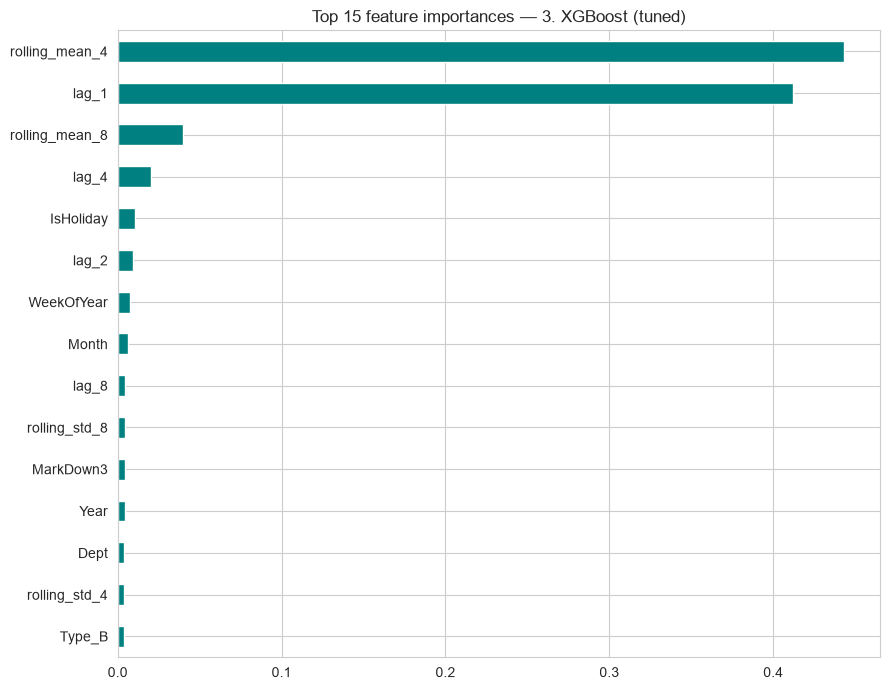

In [9]:
importances = pd.Series(best_model.feature_importances_, index=FEATURE_COLUMNS).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 7))
importances.head(15).plot(kind="barh", ax=ax, color="teal")
ax.invert_yaxis()
ax.set_title(f"Top 15 feature importances — {best_row['experiment']}")
plt.tight_layout()
plt.savefig("../reports/figures/03_feature_importance.png", dpi=120)
plt.show()

## Persist the best model for Task 4

In [10]:
joblib.dump(best_model, "../models/best_model.pkl")

metadata = {
    "experiment": best_row["experiment"],
    "feature_columns": FEATURE_COLUMNS,
    "target_column": TARGET_COLUMN,
    "split_date": SPLIT_DATE,
    "test_RMSE": float(best_row["test_RMSE"]),
    "test_MAE": float(best_row["test_MAE"]),
    "test_WMAE": float(best_row["test_WMAE"]),
}
with open("../models/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved best model -> models/best_model.pkl")
print("Saved metadata   -> models/model_metadata.json")
print(metadata)

Saved best model -> models/best_model.pkl
Saved metadata   -> models/model_metadata.json
{'experiment': '3. XGBoost (tuned)', 'feature_columns': ['Store', 'Dept', 'IsHoliday', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Size', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'Year', 'Month', 'WeekOfYear', 'lag_1', 'lag_2', 'lag_4', 'lag_8', 'rolling_mean_4', 'rolling_mean_8', 'rolling_std_4', 'rolling_std_8', 'Type_A', 'Type_B', 'Type_C'], 'target_column': 'Weekly_Sales', 'split_date': '2012-09-01', 'test_RMSE': 2742.43, 'test_MAE': 1262.01, 'test_WMAE': 1443.95}
